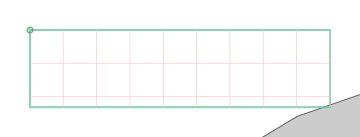

In [52]:
bbox=((-62.423159326276625,
 -64.78529211875636,
 -61.97306319590553,
 -64.66949944868482)
)

GeoBox.from_bbox(
        bbox,
        crs="EPSG:4326",
        resolution=0.0001,
    )

In [44]:
from shapely.geometry import Polygon

In [51]:
Polygon([[-62.423159326276625,-64.78529211875636],
[-61.97306319590553,-64.78529211875636],
[-61.97306319590553,-64.66949944868482],
[-62.423159326276625,-64.66949944868482],
[-62.423159326276625,-64.78529211875636]]).bounds

(-62.423159326276625,
 -64.78529211875636,
 -61.97306319590553,
 -64.66949944868482)

In [53]:
import asyncio
from aef_loader import AEFIndex, VirtualTiffReader, DataSource
from aef_loader.utils import reproject_datatree
from odc.geo.geobox import GeoBox

async def main(bbox):
    # Initialize index (Source Cooperative - no auth needed)
    index = AEFIndex(source=DataSource.SOURCE_COOP)
    await index.download()
    index.load() # returns a gdf for alternative use

    # Query for tiles
    tiles = await index.query(
        bbox=bbox,
        years=(2020, 2023),
    )

    # Load tiles organized by UTM zone
    async with VirtualTiffReader() as reader:
        tree = await reader.open_tiles_by_zone(tiles)

    # Each zone is a separate Dataset with its native CRS
    for zone in tree.children:
        ds = tree[zone].ds
        print(f"{zone}: {ds.odc.crs}, {dict(ds.sizes)}")

    # Optionally reproject all zones to a common CRS
    target = GeoBox.from_bbox(
        bbox=bbox,
        crs="EPSG:4326",
        resolution=0.0001,
    )
    combined = reproject_datatree(tree, target)
    return combined
    
ds = await main(bbox)

/Users/tblz439/aef-antarctica/.pixi/envs/default/lib/python3.14/site-packages/virtual_tiff/parser.py:55: UserWarning: Imagecodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  return ZstdCodec(level=ifd.other_tags.get(ZSTD_LEVEL_TAG, DEFAULT_ZSTD_LEVEL))
/Users/tblz439/aef-antarctica/.pixi/envs/default/lib/python3.14/site-packages/virtual_tiff/imagecodecs.py:77: UserWarning: Imagecodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  return cls(**data.get("configuration", {}))
/Users/tblz439/aef-antarctica/.pixi/envs/default/lib/python3.14/site-packages/virtual_tiff/parser.py:55: UserWarning: Imagecodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  return ZstdCodec(level=ifd.other_tags.get(ZSTD_LEVEL_TAG, DEFAULT_ZSTD_LEVEL))
/Users/tblz439/aef-antarctica/.pixi/envs/default/lib/python3.14/site-package

20S: PROJCRS["WGS 84 / UTM zone 20S",BASEGEOGCRS["WGS 84",ENSEMBLE["World Geodetic System 1984 ensemble",MEMBER["World Geodetic System 1984 (Transit)"],MEMBER["World Geodetic System 1984 (G730)"],MEMBER["World Geodetic System 1984 (G873)"],MEMBER["World Geodetic System 1984 (G1150)"],MEMBER["World Geodetic System 1984 (G1674)"],MEMBER["World Geodetic System 1984 (G1762)"],MEMBER["World Geodetic System 1984 (G2139)"],MEMBER["World Geodetic System 1984 (G2296)"],ELLIPSOID["WGS 84",6378137,298.257223563,LENGTHUNIT["metre",1]],ENSEMBLEACCURACY[2.0]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],ID["EPSG",4326]],CONVERSION["UTM zone 20S",METHOD["Transverse Mercator",ID["EPSG",9807]],PARAMETER["Latitude of natural origin",0,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8801]],PARAMETER["Longitude of natural origin",-63,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8802]],PARAMETER["Scale factor at natural origin",0.9996,SCALEUNIT["unity",1],ID["EPSG",8805]],PARAMETER["Fa

<xarray.Dataset> Size: 1GB
Dimensions:      (time: 4, band: 64, latitude: 1158, longitude: 4502)
Coordinates:
  * time         (time) datetime64[us] 32B 2020-01-01 2021-01-01 ... 2023-01-01
  * band         (band) <U3 768B 'A00' 'A01' 'A02' 'A03' ... 'A61' 'A62' 'A63'
  * latitude     (latitude) float64 9kB -64.67 -64.67 -64.67 ... -64.79 -64.79
  * longitude    (longitude) float64 36kB -62.42 -62.42 -62.42 ... -61.97 -61.97
    spatial_ref  int32 4B 4326
Data variables:
    embeddings   (time, band, latitude, longitude) int8 1GB dask.array<chunksize=(1, 5, 1158, 4502), meta=np.ndarray>
Attributes:
    utm_zone:     20S
    num_tiles:    4
    source_zone:  20S

In [56]:
_ds = ds.to_zarr('aef_embeddings.zarr', compute=False)

/Users/tblz439/aef-antarctica/.pixi/envs/default/lib/python3.14/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=3, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/Users/tblz439/aef-antarctica/.pixi/envs/default/lib/python3.14/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Delayed('_finalize_store-88048f1a-5ab7-4680-9f34-7f8f3273d5d6')

In [63]:
from dask.diagnostics import ProgressBar

In [64]:
with ProgressBar():
    _ds.compute()

[#####                                   ] | 12% Completed | 45.38 ss

/Users/tblz439/aef-antarctica/.pixi/envs/default/lib/python3.14/site-packages/rasterio/warp.py:385: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


[########################################] | 100% Completed | 159.27 s


In [79]:
import xarray as xr
import matplotlib.pyplot as plt

In [80]:
ds = xr.open_zarr('aef_embeddings.zarr')
ds

<xarray.Dataset> Size: 5GB
Dimensions:      (time: 4, band: 64, latitude: 1158, longitude: 4502)
Coordinates:
  * time         (time) datetime64[ns] 32B 2020-01-01 2021-01-01 ... 2023-01-01
  * band         (band) <U3 768B 'A00' 'A01' 'A02' 'A03' ... 'A61' 'A62' 'A63'
  * latitude     (latitude) float64 9kB -64.67 -64.67 -64.67 ... -64.79 -64.79
  * longitude    (longitude) float64 36kB -62.42 -62.42 -62.42 ... -61.97 -61.97
Data variables:
    embeddings   (time, band, latitude, longitude) float32 5GB dask.array<chunksize=(1, 5, 1158, 4502), meta=np.ndarray>
    spatial_ref  int32 4B ...
Attributes:
    utm_zone:     20S
    num_tiles:    4
    source_zone:  20S

In [98]:
epsg_3031 = ccrs.Stereographic(central_latitude=-90, true_scale_latitude=-71)

In [124]:
def set_extent(ax):
    ax.set_extent(bbox, crs=ccrs.PlateCarree())

In [135]:
import cartopy.crs as ccrs
import numpy as np

In [149]:
da = ds.isel(time=0).embeddings#
de_quantized_values = ((da / 127.5) ** 2) * np.sign(da)
# de_quantized_values.plot(subplot_kws={'projection':epsg_3031}, transform=ccrs.PlateCarree())

In [182]:
import rioxarray
import numpy as np
from sklearn.cluster import KMeans

# Load a single year tile (64 bands)
da = de_quantized_values

# Reshape to (pixels, 64)
arr = da.values.reshape(64, -1).T  # (H*W, 64)

# Mask nodata
valid = ~np.isnan(arr).any(axis=1)
X = arr[valid]

# Cluster — embeddings are already unit-length, so cosine distance 
# is equivalent; KMeans with euclidean works fine on the unit sphere too
km = KMeans(n_clusters=2, random_state=42, n_init="auto")

labels = km.fit_predict(X)

# Reconstruct spatial array
result = np.full(arr.shape[0], -1)
result[valid] = labels
result = result.reshape(da.shape[1], da.shape[2])

In [179]:
import rioxarray
import numpy as np
from sklearn.mixture import GaussianMixture

# Load a single year tile (64 bands)
da = de_quantized_values

# Reshape to (pixels, 64)
arr = da.values.reshape(64, -1).T  # (H*W, 64)

# Mask nodata
valid = ~np.isnan(arr).any(axis=1)
X = arr[valid]

# Fit GMM
gmm = GaussianMixture(n_components=2, covariance_type="diag", random_state=42, n_init=5)
gmm.fit(X)

labels = gmm.predict(X)
probs  = gmm.predict_proba(X)[:, 1]

# Reconstruct spatial arrays
H, W = da.shape[1], da.shape[2]

label_map = np.full(H * W, -1, dtype=np.int8)
label_map[valid] = labels
label_map = label_map.reshape(H, W)

prob_map = np.full(H * W, np.nan)
prob_map[valid] = probs
prob_map = prob_map.reshape(H, W)

In [183]:
result_da = da.isel(band=1).copy()
result_da.values = result

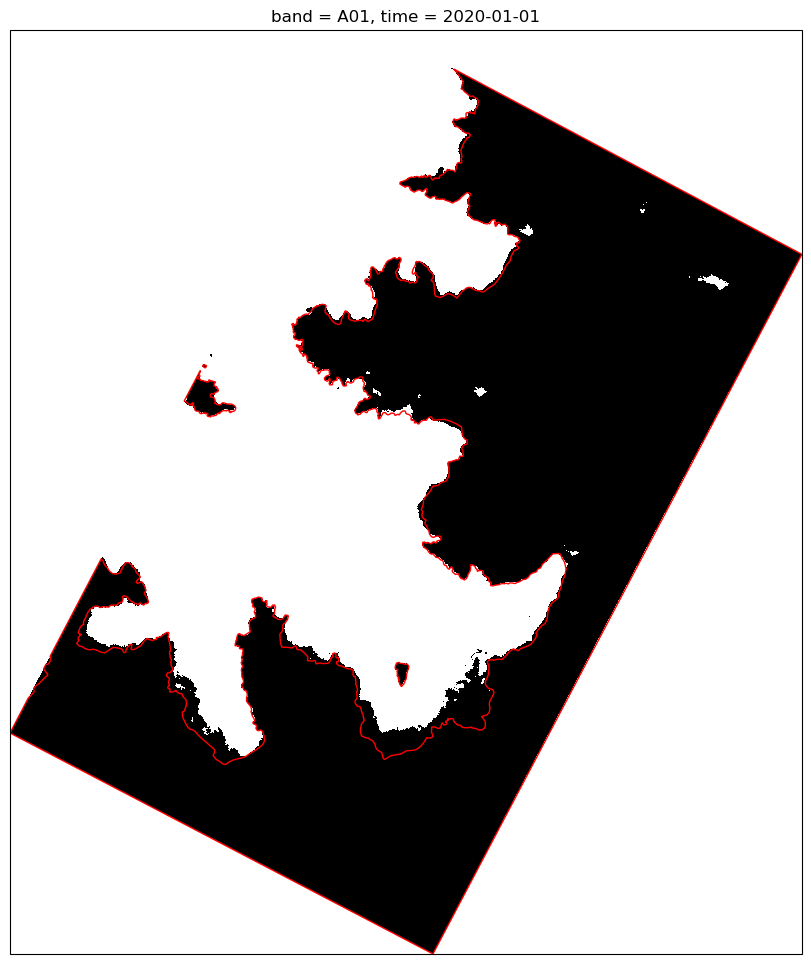

In [185]:
fig = plt.figure(figsize=(12,12))
ax = plt.axes(projection=epsg_3031)

result_da.plot(ax=ax, cmap='binary_r', add_colorbar=False, transform=ccrs.PlateCarree())
roi.to_crs(epsg_3031).plot(ax=ax, facecolor='none', edgecolor='r')
plt.show()

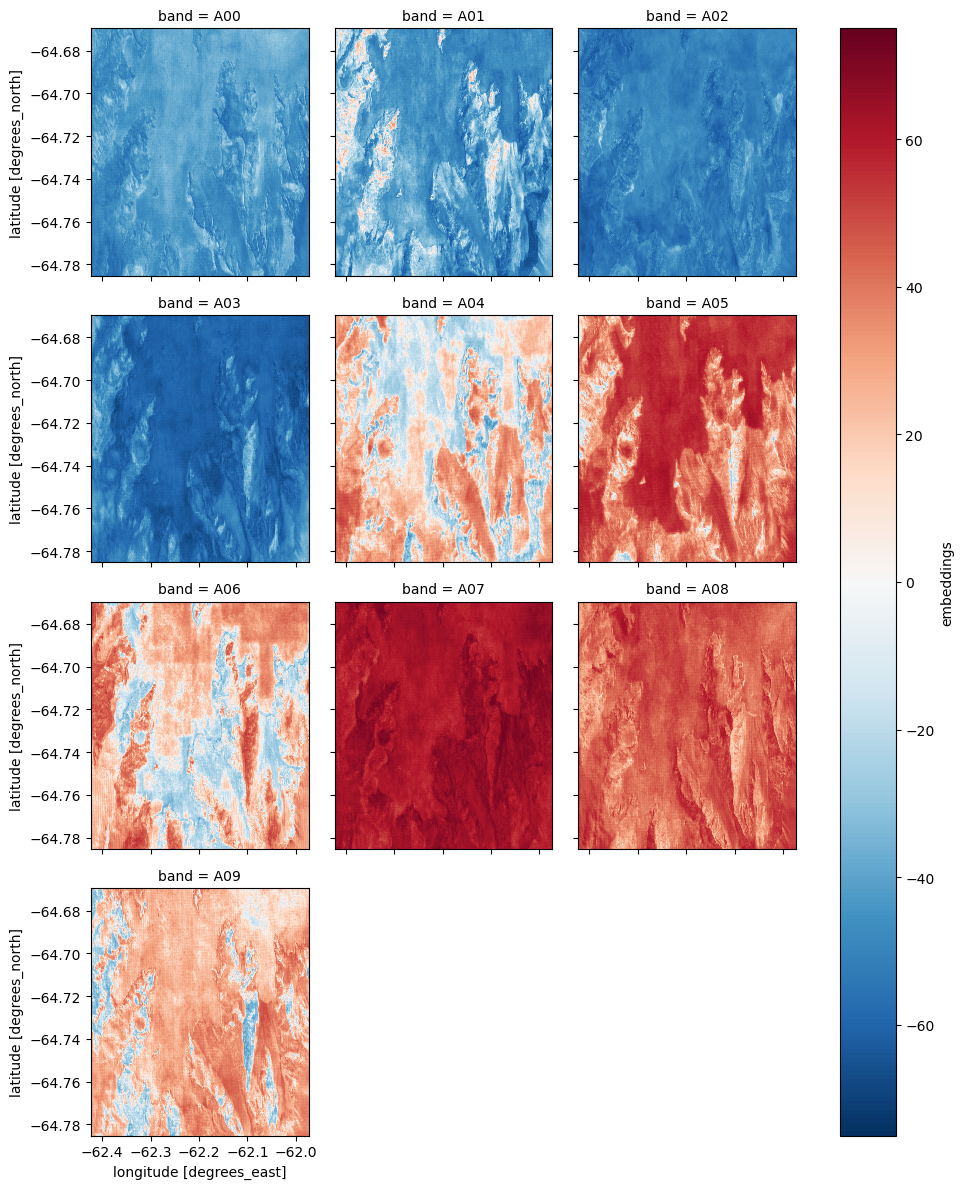

In [131]:
fg = ds.isel(time=0).embeddings.sel(band=[f"A{str(i).zfill(2)}" for i in range(0,10)]).plot(col='band', col_wrap=3)
# for ax in fg.axs.flat:
    # set_extent(ax)

In [ ]:
transform=ccrs.PlateCarree(), subplot_kws={'projection':epsg_3031}

In [ ]:
fg

In [161]:
import geopandas as gpd
roi = gpd.read_file('add_coastline_high_res_polygon_v7_11.shp.zip').to_crs('EPSG:4326').clip(bbox)

<Axes: >

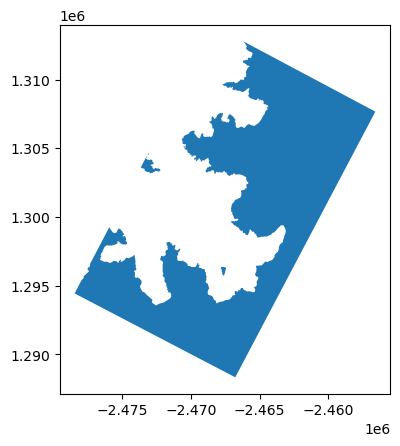

In [162]:
roi.to_crs('EPSG:3031').plot()